In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [4]:
output_base = "./high-ecc-schw/"

In [75]:
output_file = os.path.join(output_base, "amplitude_mag_phase.h5")
with h5py.File(output_file, 'r') as f:
    psi_r_loaded = f["psi_r"][:]
    e_amp_loaded     = f["e"][:]
    dp_amp_loaded    = f["dp"][:]
    mag_loaded   = f["magnitude"][:]   # (n_dp, n_e, N_psi)
    phase_loaded = f["phase"][:]

print(f"psi_r:     {psi_r_loaded.shape}")
print(f"e:         {e_amp_loaded.shape}  ->  {e_amp_loaded}")
print(f"dp:        {dp_amp_loaded.shape}")
print(f"magnitude: {mag_loaded.shape}  (n_dp, n_e, N_psi)")
print(f"phase:     {phase_loaded.shape}")

phase_loaded = np.unwrap(phase_loaded, axis=-1)

real_loaded = mag_loaded * np.cos(phase_loaded)
imag_loaded = - mag_loaded * np.sin(phase_loaded)

amps_loaded = real_loaded + 1j * imag_loaded

psi_r:     (512,)
e:         (21,)  ->  [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
dp:        (20,)
magnitude: (20, 21, 512)  (n_dp, n_e, N_psi)
phase:     (20, 21, 512)


In [139]:
fourier_coefficients = (np.fft.fft(amps_loaded, axis=-1))

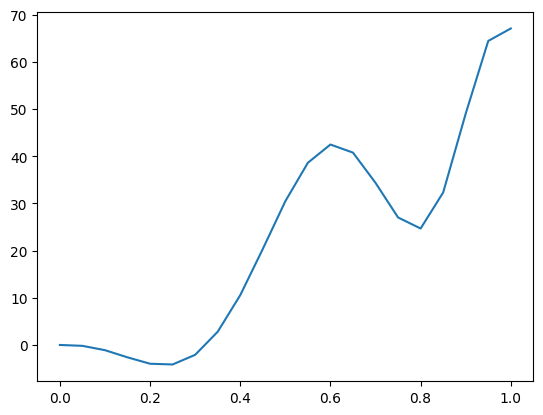

In [ ]:
plt.plot(e_amp_loaded, (fourier_coefficients[10,:,1].real))

Text(0.5, 0, '$\\log_{10}(\\Delta p)$')

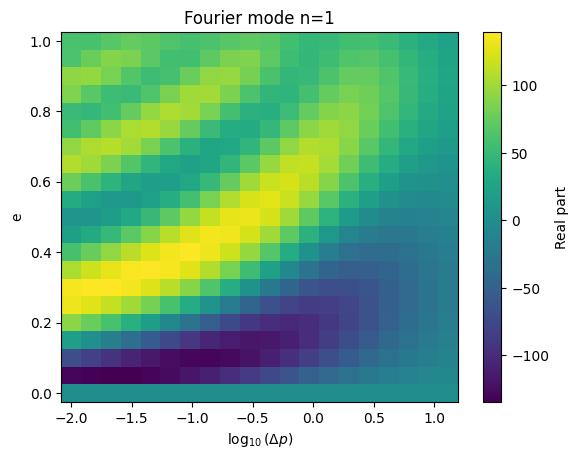

In [205]:
idx = 1
plt.pcolormesh(np.log10(dp_amp_loaded), e_amp_loaded, np.real(fourier_coefficients[:, :, idx]).T, shading='auto')
plt.colorbar(label="Real part")
plt.title(f"Fourier mode n={idx}")
plt.ylabel("e")
plt.xlabel(r"$\log_{10}(\Delta p)$")